

# Módulo 4 - Big Data
Proyecto Final 
Estudiante: Jairo Prado

### Descripción de los datos 

En este proyecto se utilizaron los siguientes datasets:

1) Datasets de educación por edad y sexo de Sinirube: estos datos presentan el nivel de educación por edad y sexo a nivel cantonal y distrital en Costa Rica.

2) Atlas de Desarrollo Humano Cantonal: El dataset de Atlas de Desarrollo Humano Cantonal aporta índices de desarrollo a nivel cantonal de la población costarricense. En este proyecto se utilizaron los índices más recientes del año 2020.

3) Estadísticas policiales del OIJ: se utilizaron las estadísticas policiales desde el 01/04/2024 hasta el 21/10/2025.

# Lectura de los datos desde la base de datos

In [1]:
# Cargar el conjunto de datos completo
import findspark
findspark.init('/usr/lib/python3.7/site-packages/pyspark')

from pyspark.sql.types import (StringType, IntegerType, FloatType, 
                               DecimalType, StructField, StructType, DoubleType)

from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Basic JDBC pipeline") \
    .config("spark.driver.extraClassPath", "postgresql-42.2.14.jar") \
    .config("spark.executor.extraClassPath", "postgresql-42.2.14.jar") \
    .getOrCreate()
    
df_datos = spark \
    .read \
    .format("jdbc") \
    .option("url", "jdbc:postgresql://172.17.0.1:5433/postgres") \
    .option("user", "postgres") \
    .option("password", "testPassword") \
    .option("dbtable", "DatosUnidos") \
    .load()

df_datos.show()

ps: unrecognized option: p
BusyBox v1.30.1 (2019-06-12 17:51:55 UTC) multi-call binary.

Usage: ps [-o COL1,COL2=HEADER]

Show list of processes

	-o COL1,COL2=HEADER	Select columns for display
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/15 22:35:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
/usr/lib/python3.7/site-packages/pyspark/context.py:317: FutureWarning: Python 3.7 support is deprecated in Spark 3.4.
  warnings.warn("Python 3.7 support is deprecated in Spark 3.4.", FutureWarning)


+-------+----------+-------------+-------+-------------+------------+-------------+------------------+------+---------------------+---------------+---------------------+-------------+-----------------------+------------------+
| Canton| Provincia|ASALTO_ARMADO|Victima| Edad_Victima|Sexo_Victima|Total_Asaltos|   Nivel_Educativo|  Sexo|Total_Personas_Canton|IngresoPromedio|IndiceDesarolloHumano|EsperanzaVida|IndiceBienestarMaterial|IndiceConocimiento|
+-------+----------+-------------+-------+-------------+------------+-------------+------------------+------+---------------------+---------------+---------------------+-------------+-----------------------+------------------+
|GOLFITO|PUNTARENAS|           NO|PERSONA|Mayor de edad|      HOMBRE|            6|ENSEÑANZA ESPECIAL|Hombre|                  348|       308996,2|                0,729|       82,180|                  0,608|             0,692|
|GOLFITO|PUNTARENAS|           NO|PERSONA| Adulto Mayor|      HOMBRE|            1|ENSEÑANZA

In [2]:
# Analisys de nulos.
from pyspark.sql.functions import col, sum as _sum, when

cols = ['Canton','Provincia','Victima','Edad_Victima','Sexo_Victima','Total_Asaltos','Nivel_Educativo','Sexo','Total_Personas_Canton','IngresoPromedio','IndiceDesarolloHumano','EsperanzaVida','IndiceBienestarMaterial','IndiceConocimiento', 'ASALTO_ARMADO']

#  null counts
null_counts_row = df_datos.select([
    _sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in cols
]).collect()[0].asDict()

# mostrar
print("\n Cuenta de nulos por columna:\n")
for col_name, count in sorted(null_counts_row.items(), key=lambda x: x[1], reverse=True):
    print(f"{col_name:40s} {count}")



 Cuenta de nulos por columna:

Canton                                   0
Provincia                                0
Victima                                  0
Edad_Victima                             0
Sexo_Victima                             0
Total_Asaltos                            0
Nivel_Educativo                          0
Sexo                                     0
Total_Personas_Canton                    0
IngresoPromedio                          0
IndiceDesarolloHumano                    0
EsperanzaVida                            0
IndiceBienestarMaterial                  0
IndiceConocimiento                       0
ASALTO_ARMADO                            0


In [3]:
# Comvertirlos valores a float
from pyspark.sql.functions import regexp_replace, col

numeric_cols = ['IngresoPromedio','IndiceDesarolloHumano','EsperanzaVida',
                'IndiceBienestarMaterial','IndiceConocimiento']

for c in numeric_cols:
    # Remover comas y pasa a float 
    df_datos = df_datos.withColumn(c, 
                  regexp_replace(col(c), ",", "").cast("float"))



In [4]:
#convertig SI a 1 y NO a 0

from pyspark.sql.functions import col, when, upper, trim

df_datos = df_datos.withColumn(
    "ASALTO_ARMADO_NUM",
    when(upper(trim(col("ASALTO_ARMADO"))) == "SI", 1).otherwise(0)
)


In [5]:
# Analisis de nulos.
from pyspark.sql.functions import col, sum as _sum, when

cols = ['Canton','Provincia','Victima','Edad_Victima','Sexo_Victima','Total_Asaltos','Nivel_Educativo','Sexo','Total_Personas_Canton','IngresoPromedio','IndiceDesarolloHumano','EsperanzaVida','IndiceBienestarMaterial','IndiceConocimiento', 'ASALTO_ARMADO']

#  null counts
null_counts_row = df_datos.select([
    _sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in cols
]).collect()[0].asDict()

# mostrar
print("\n Cuenta de nulos por columna:\n")
for col_name, count in sorted(null_counts_row.items(), key=lambda x: x[1], reverse=True):
    print(f"{col_name:40s} {count}")



 Cuenta de nulos por columna:

Canton                                   0
Provincia                                0
Victima                                  0
Edad_Victima                             0
Sexo_Victima                             0
Total_Asaltos                            0
Nivel_Educativo                          0
Sexo                                     0
Total_Personas_Canton                    0
IngresoPromedio                          0
IndiceDesarolloHumano                    0
EsperanzaVida                            0
IndiceBienestarMaterial                  0
IndiceConocimiento                       0
ASALTO_ARMADO                            0


In [6]:
# Analisis de duplicados 

duplicates = df_datos.groupBy(cols) \
               .count() \
               .filter(col("count") > 1)

# Just show how many duplicate rows exist
num_duplicate_rows = duplicates.count()

print(f"Numero de filas duplicadas {num_duplicate_rows}")



Numero de filas duplicadas 0


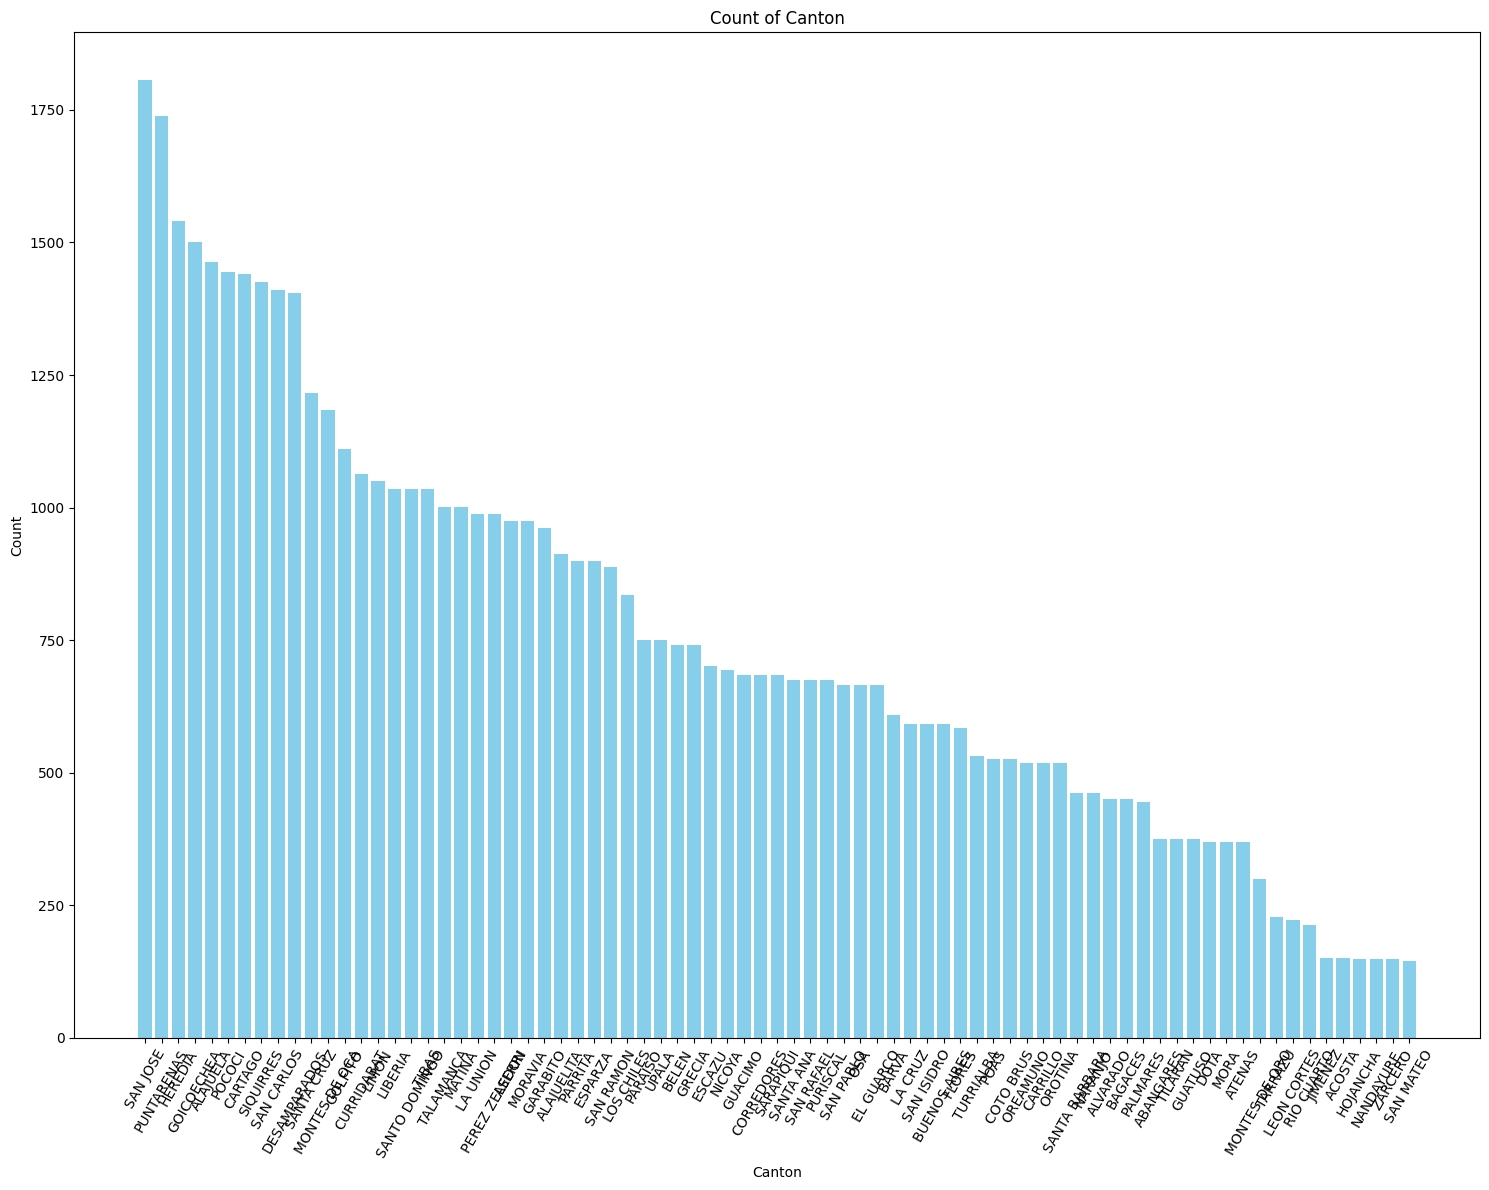

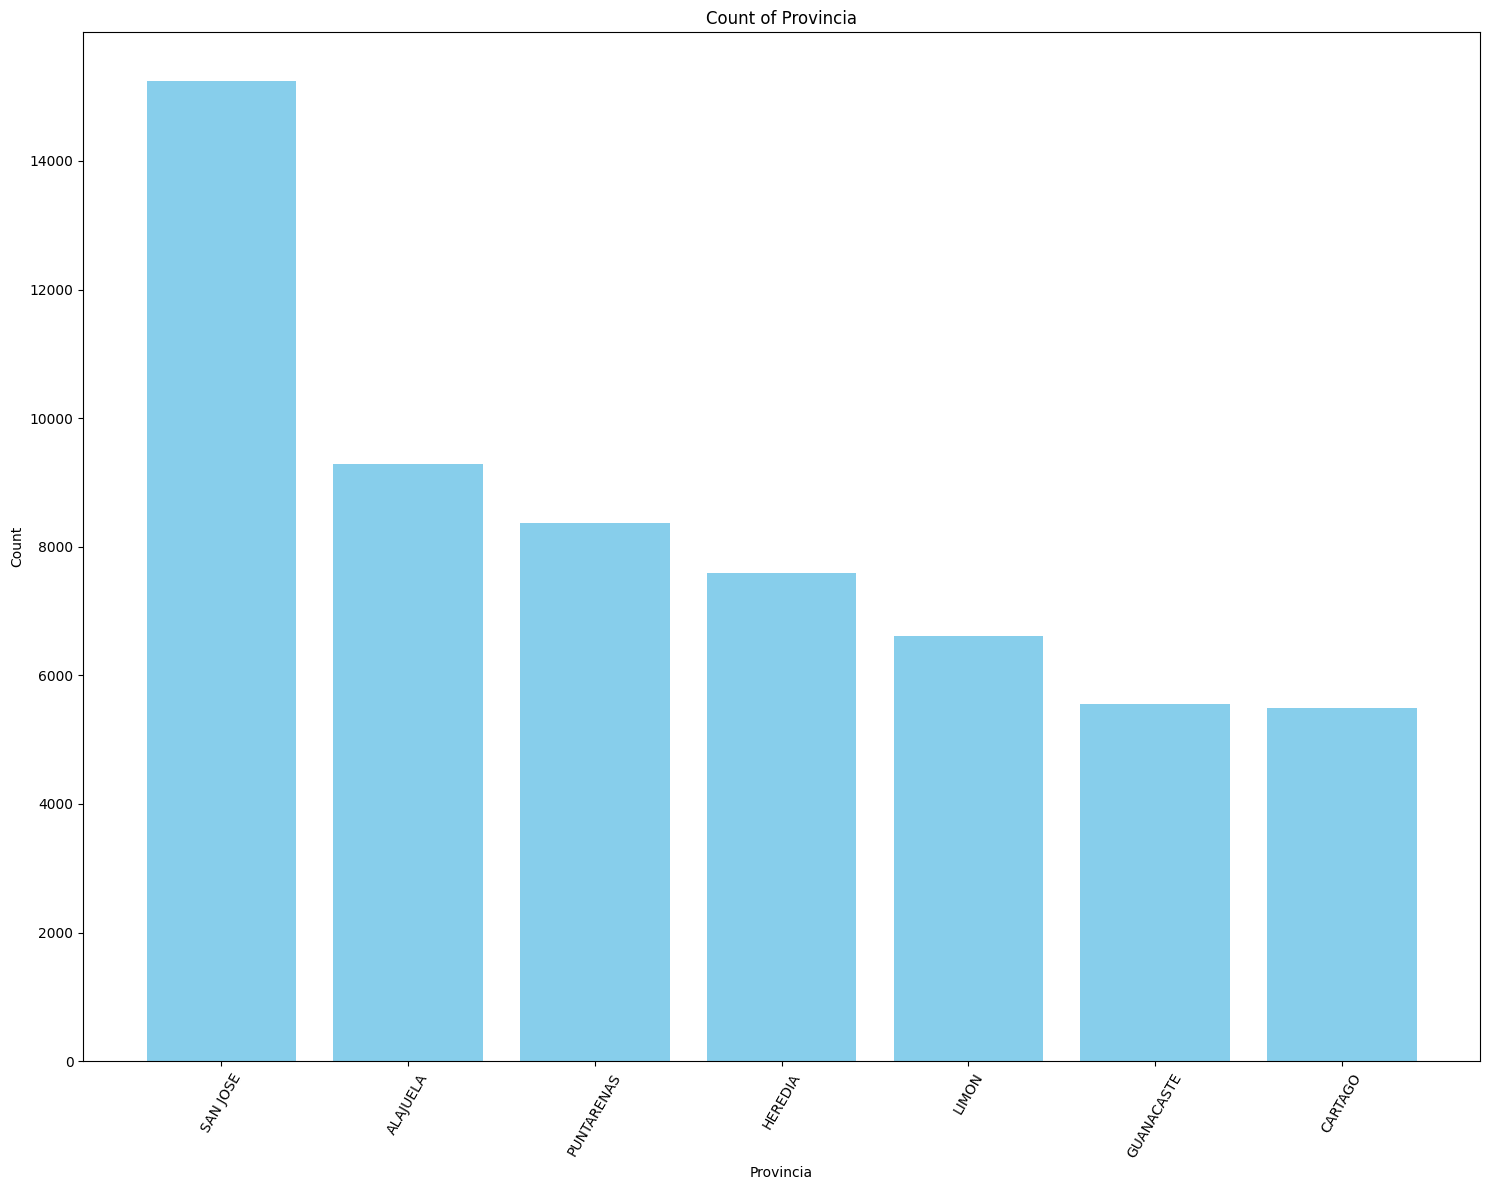

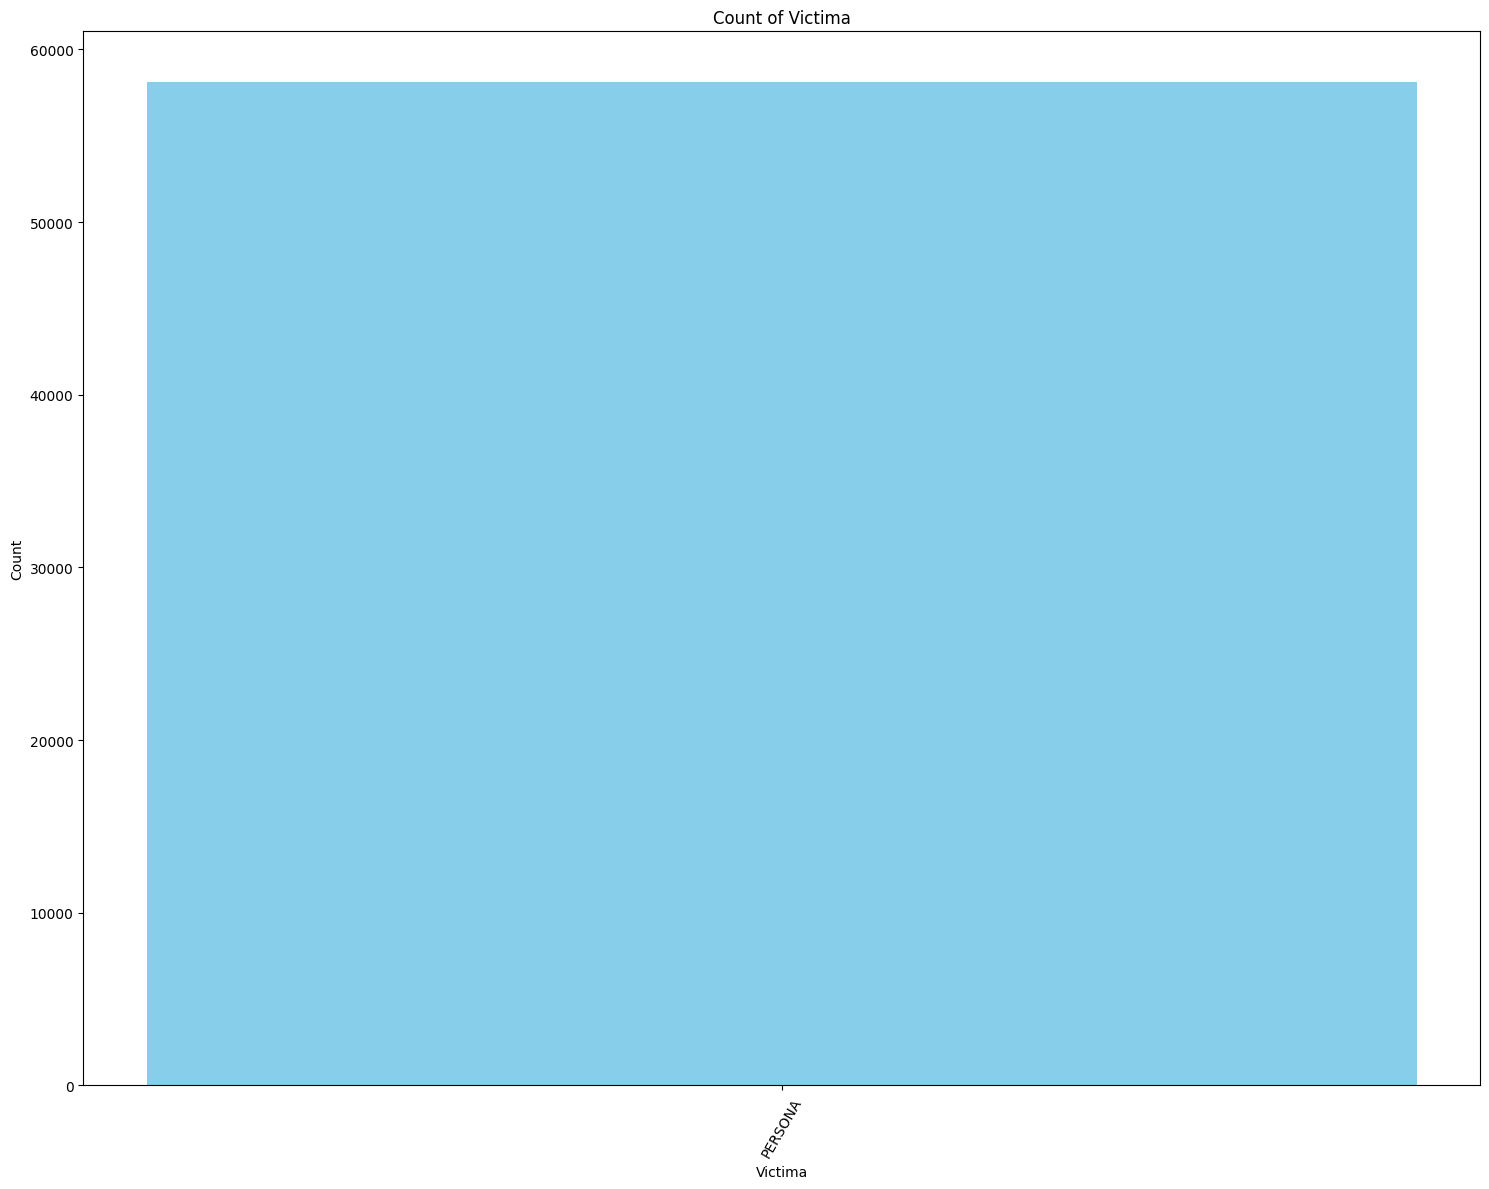

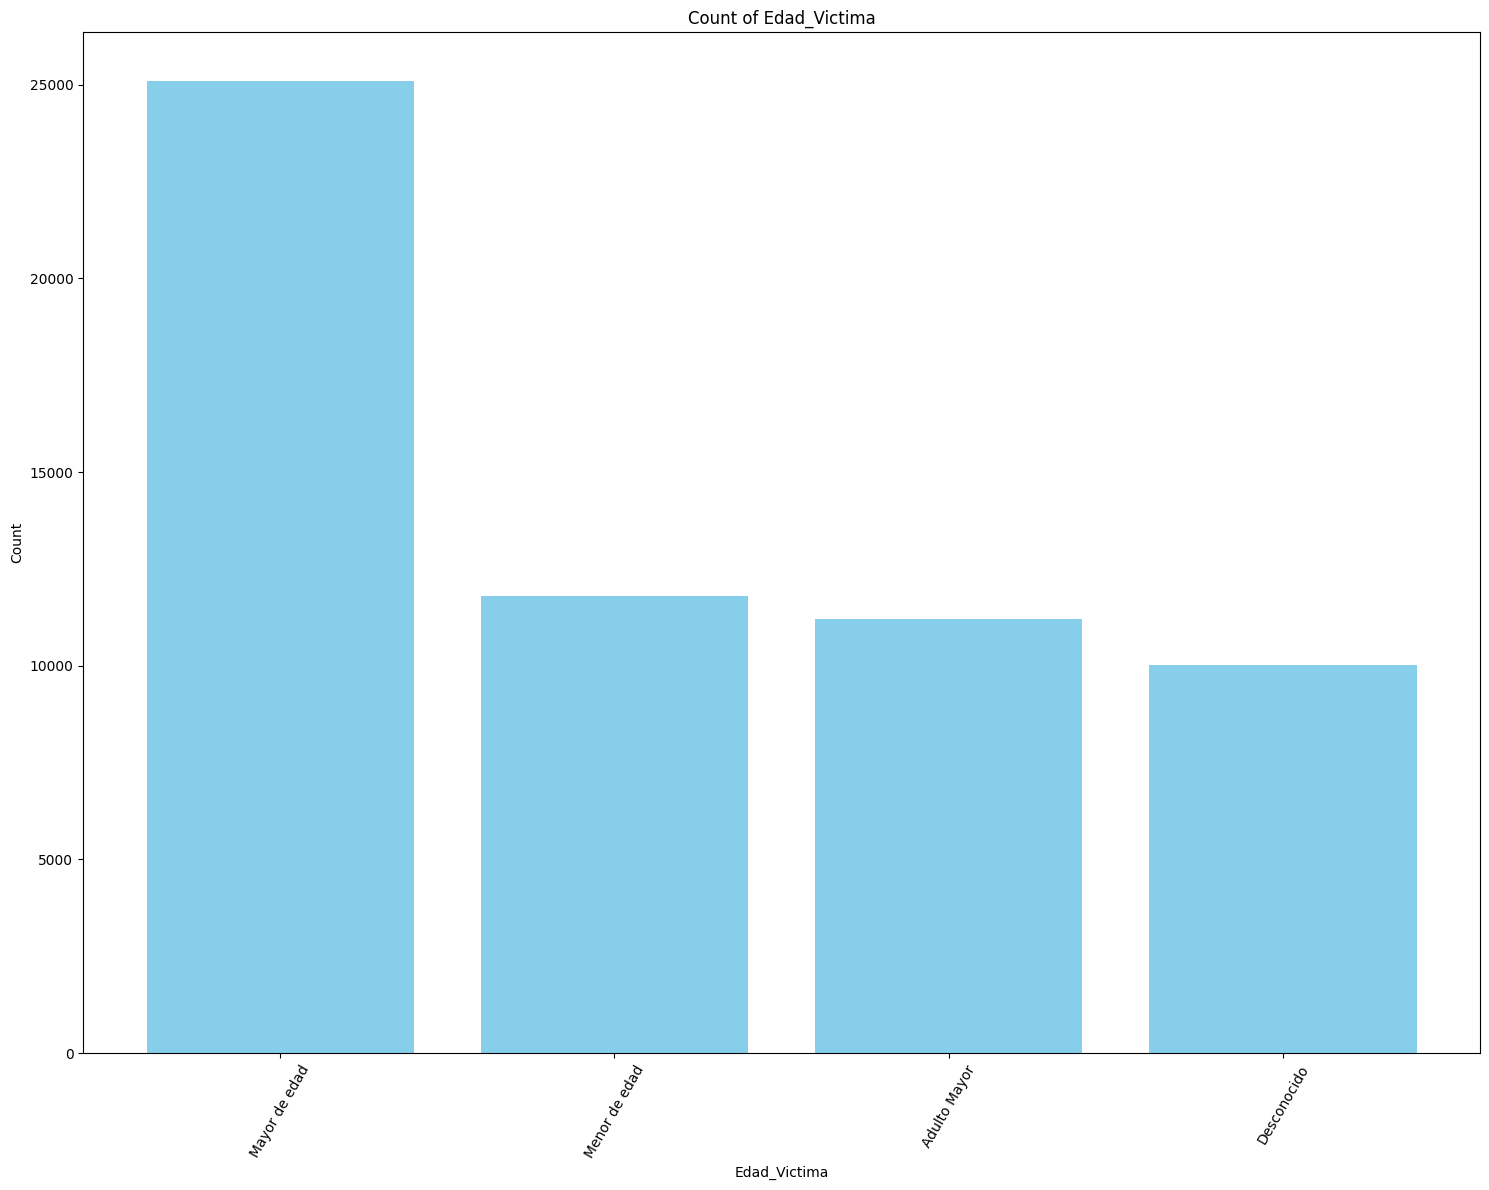

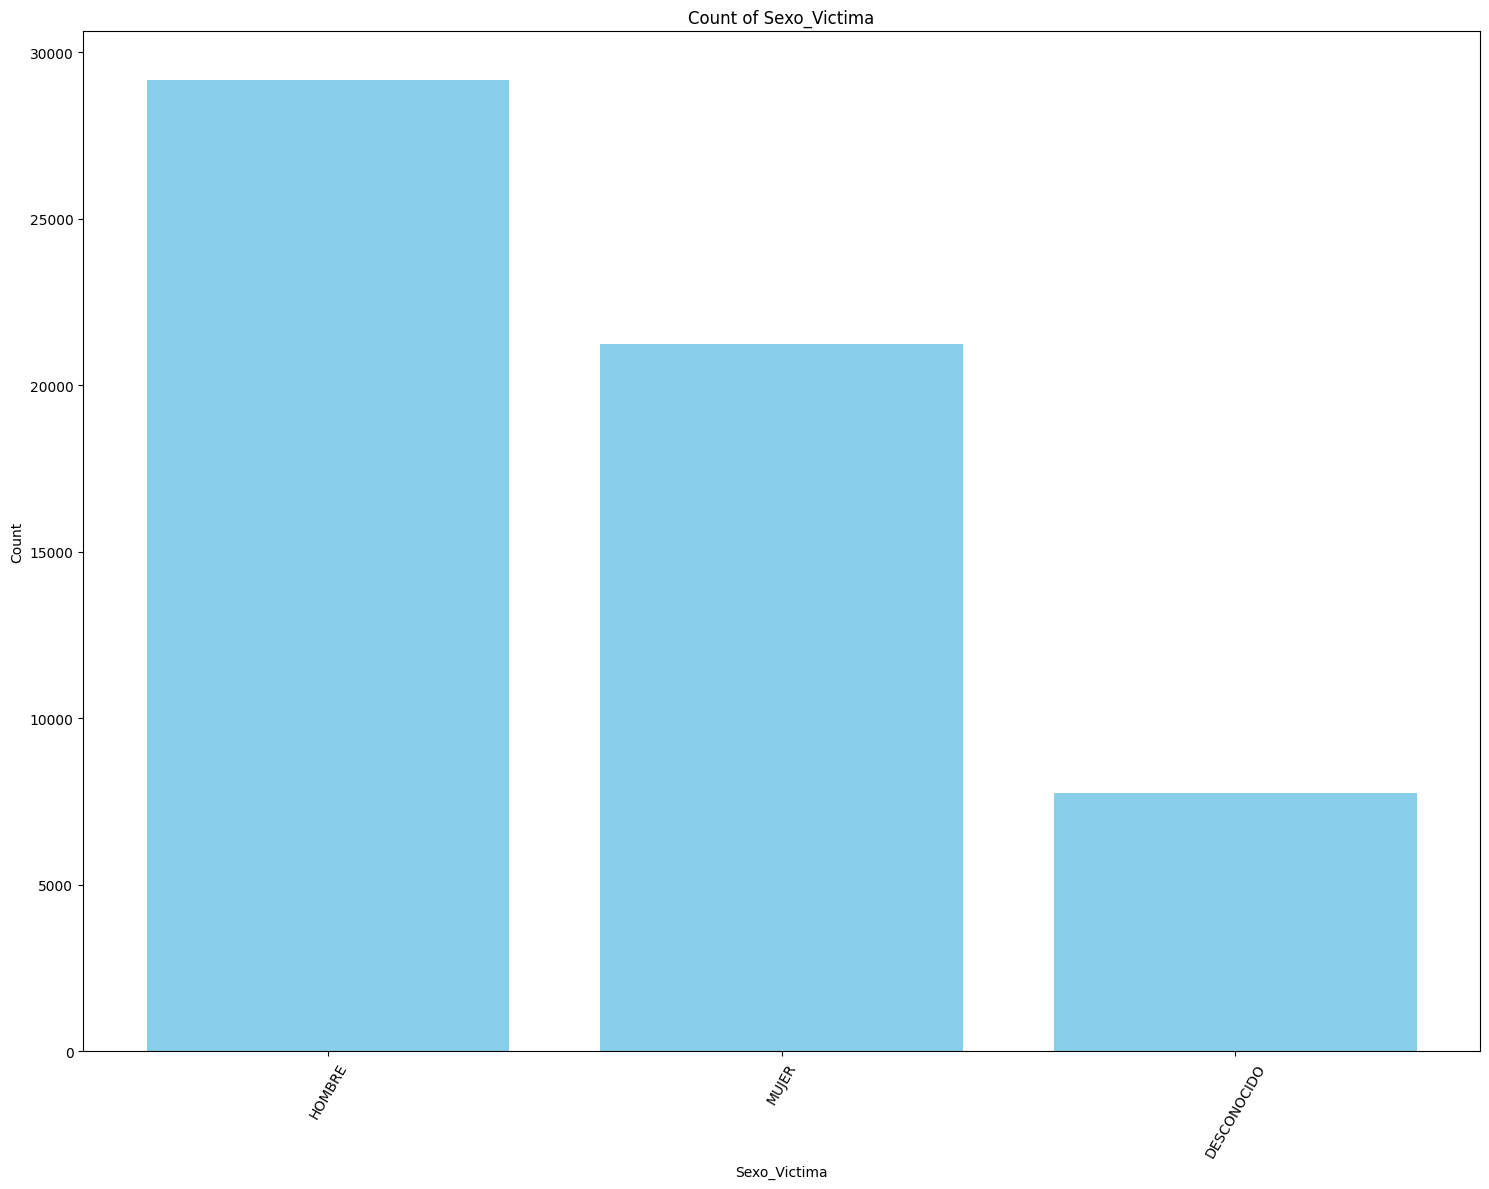

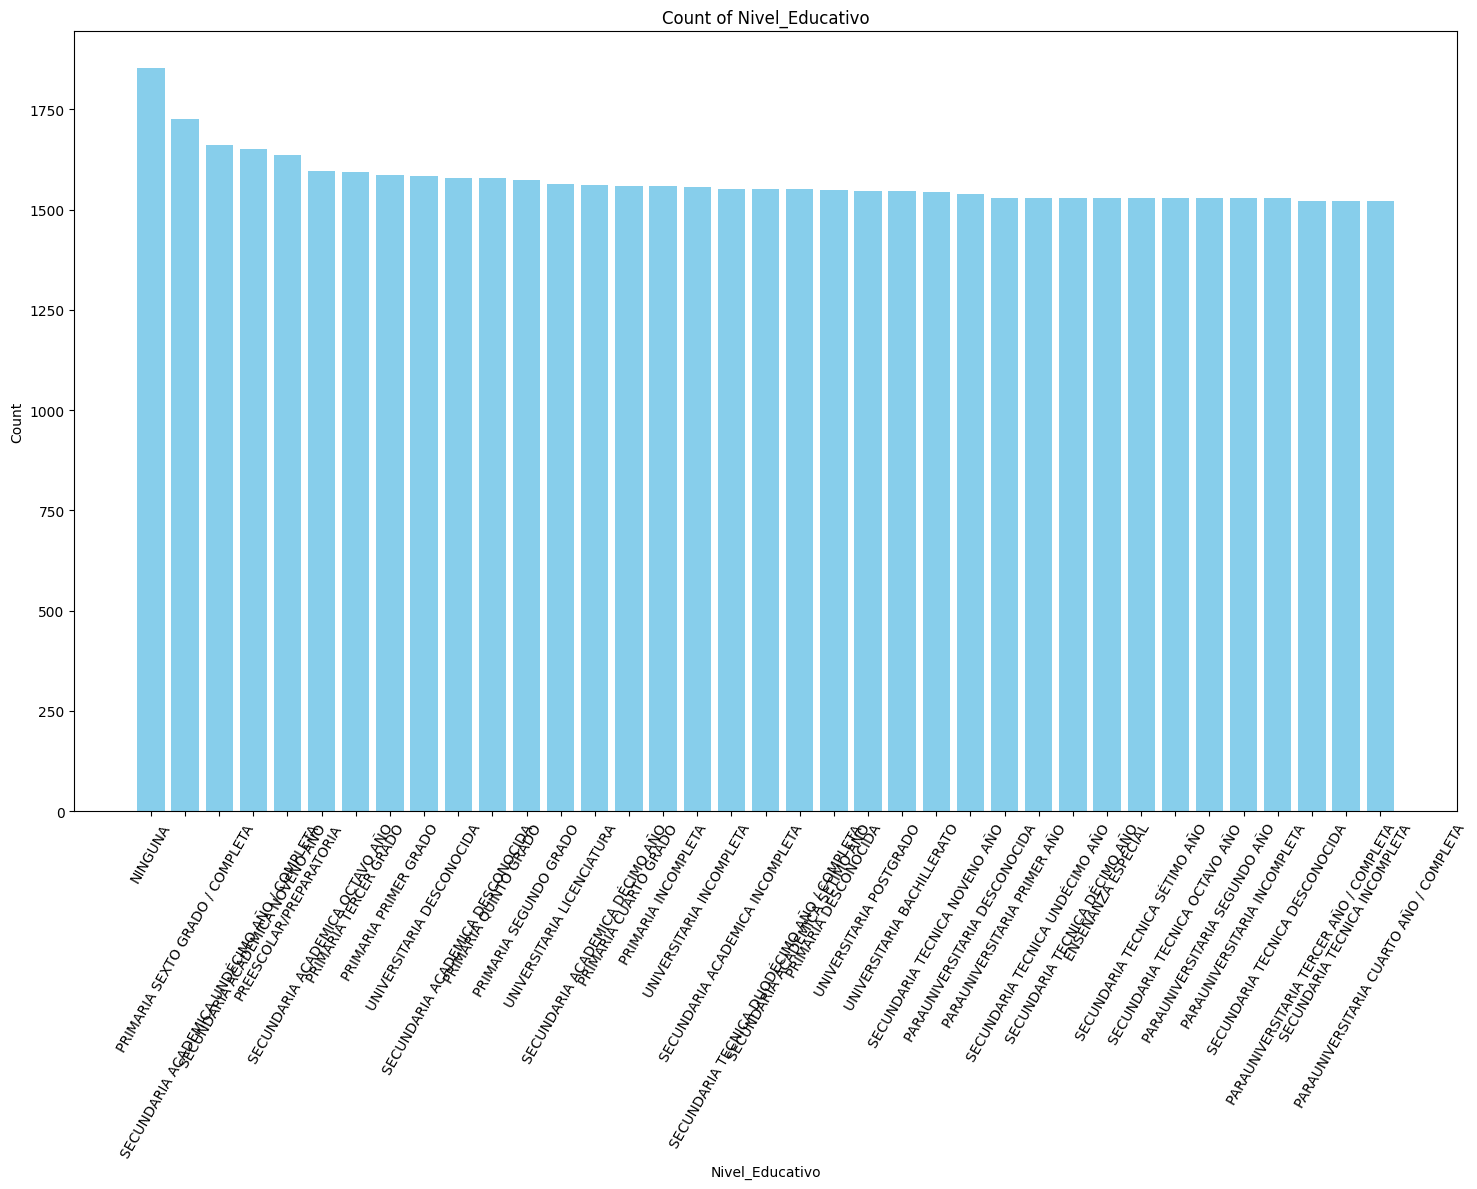

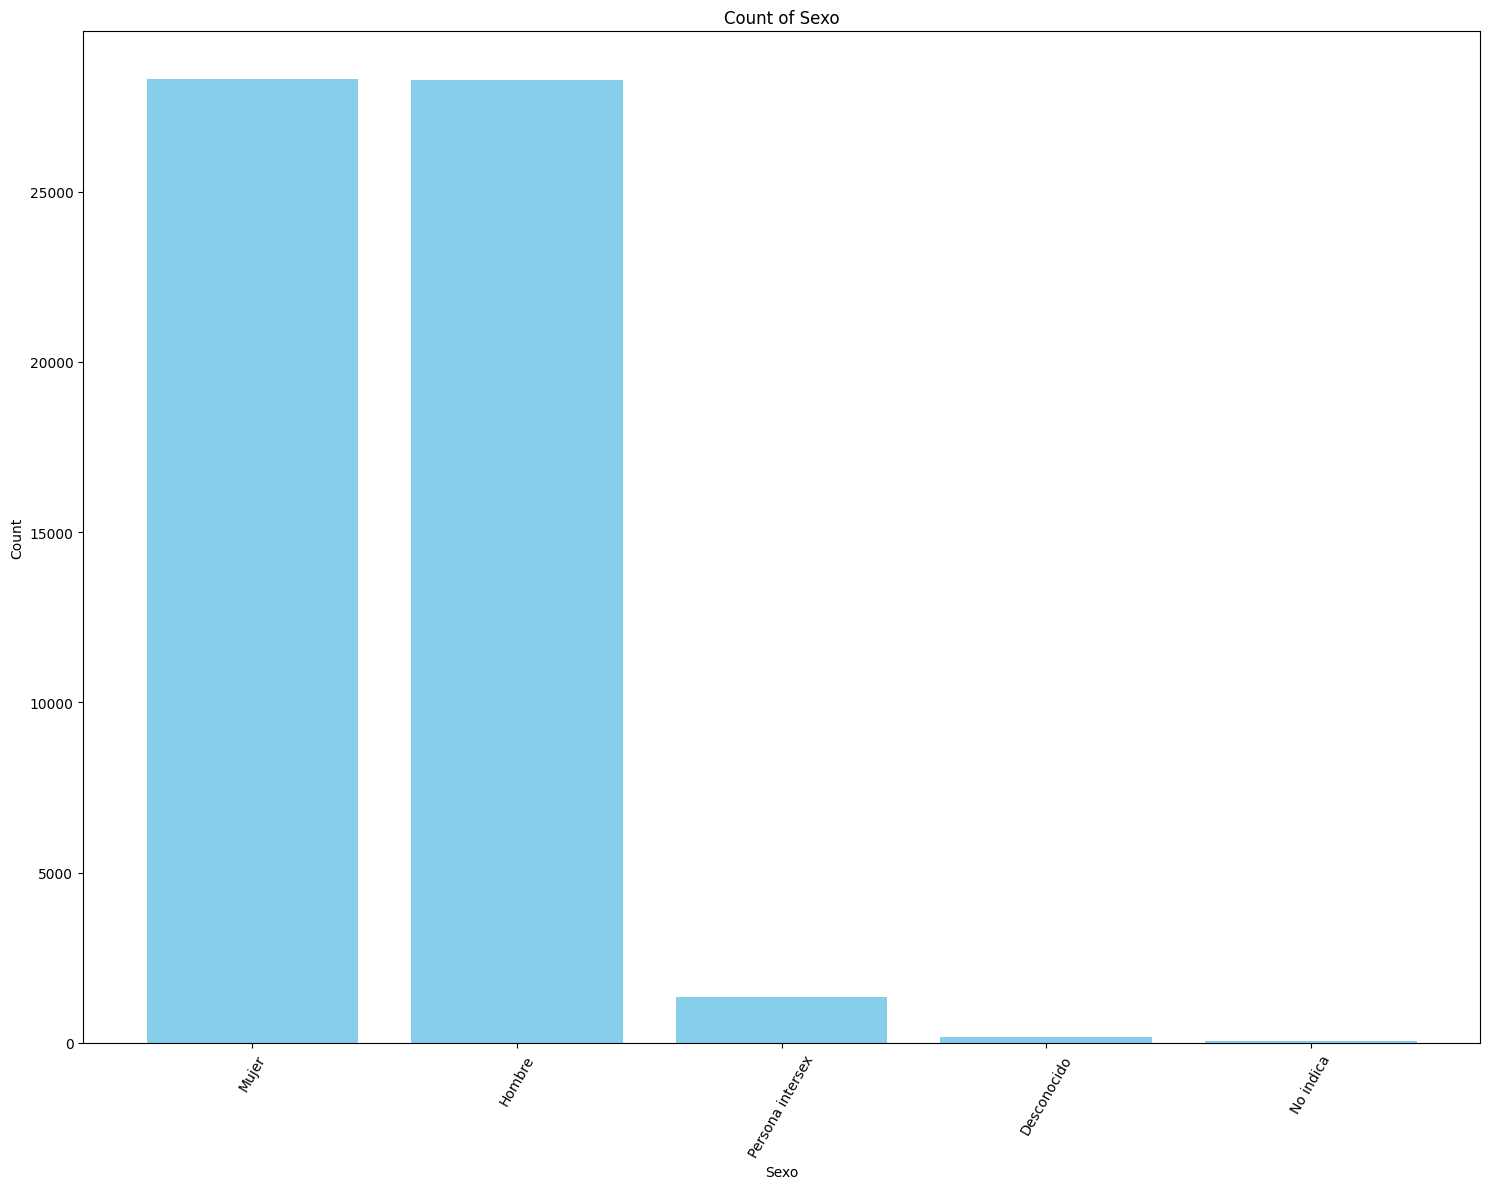

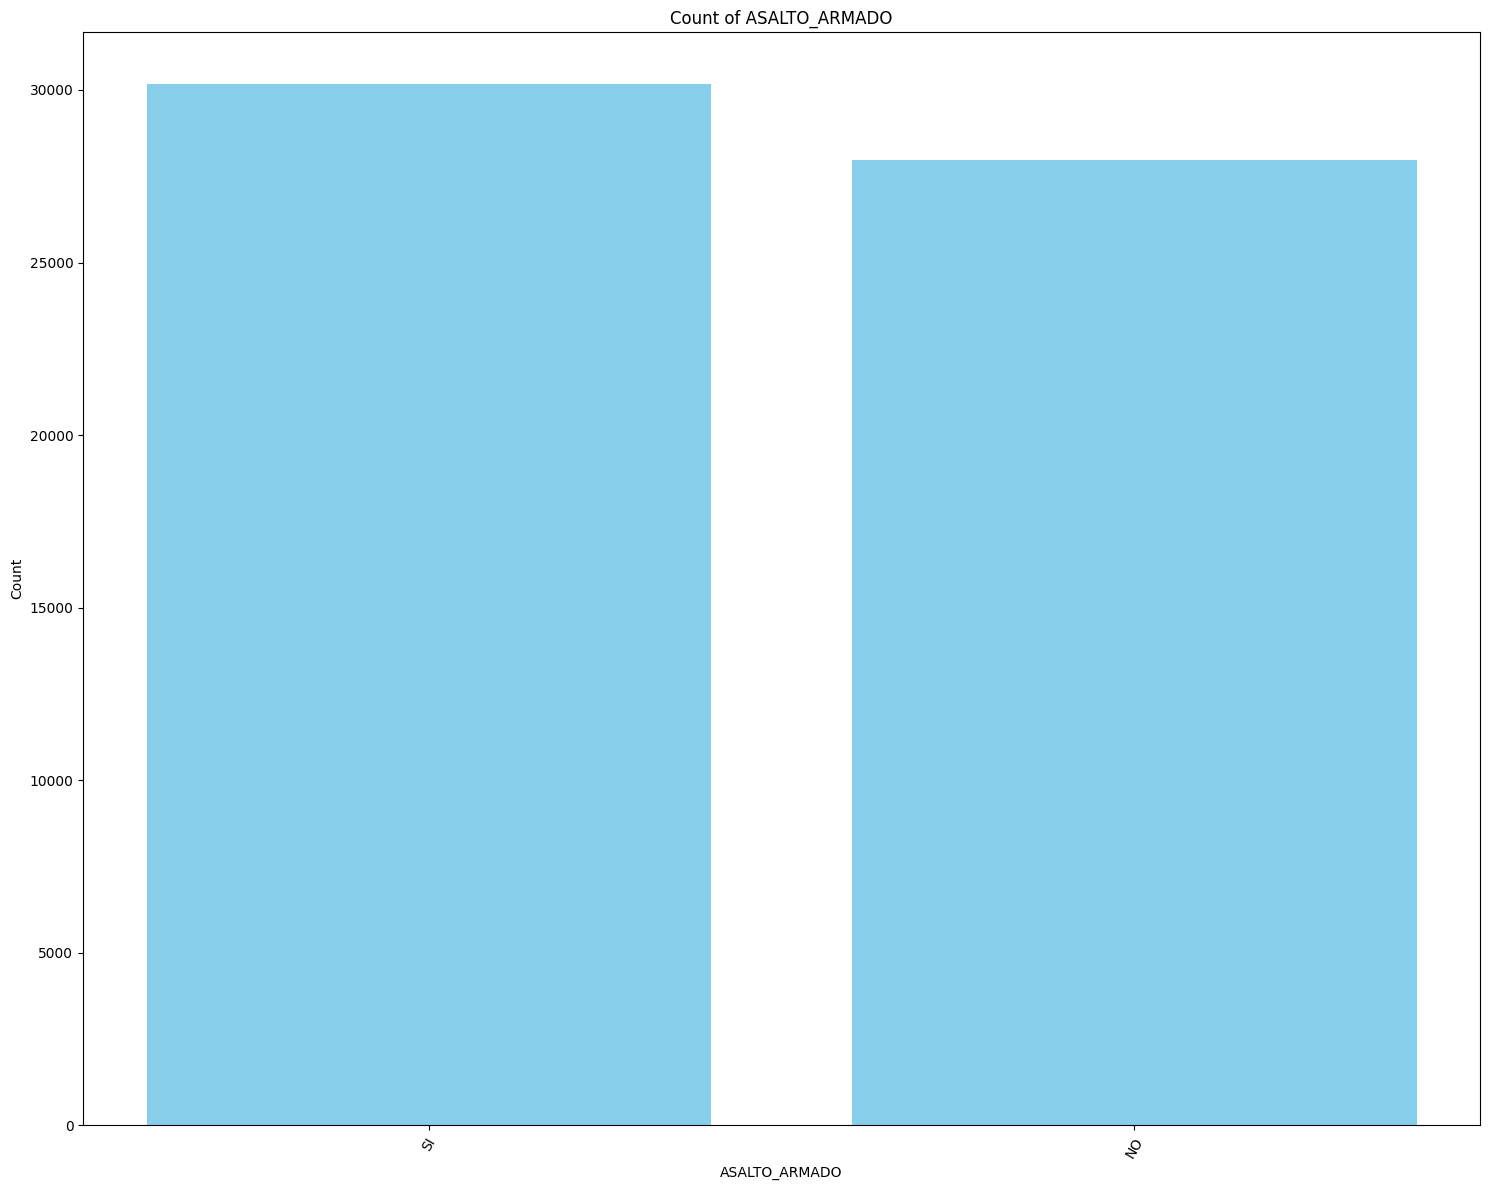

In [7]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np

categorical_cols = ['Canton','Provincia','Victima','Edad_Victima','Sexo_Victima','Nivel_Educativo','Sexo','ASALTO_ARMADO']

for col in categorical_cols:
    counts = df_datos.groupBy(col).count().orderBy('count', ascending=False).toPandas()
    
    # Crear x positiones en rango  range(len(categories))
    x_pos = np.arange(len(counts[col]))
    
    plt.figure(figsize=(15,12))
    plt.bar(x_pos, counts['count'], color='skyblue')
    
    # añadir el las etiquetas del eje x y rotar 
    plt.xticks(x_pos, counts[col], rotation=60)
    
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()  # Ajustar distribucion  para evitar corte de etiqutas
    plt.show()


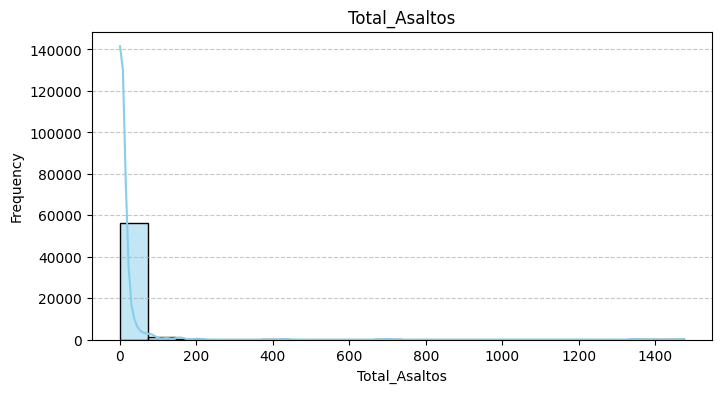

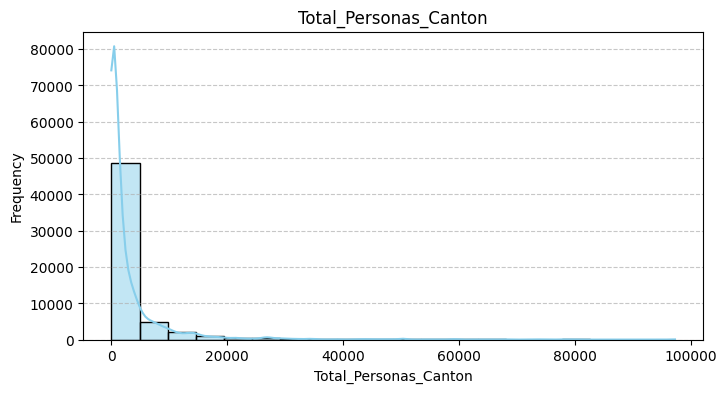

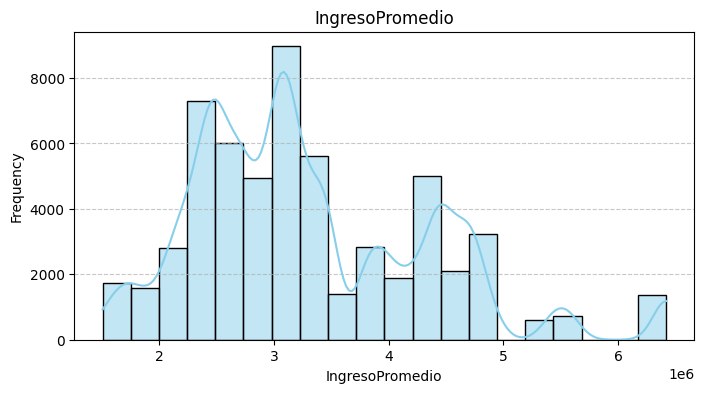

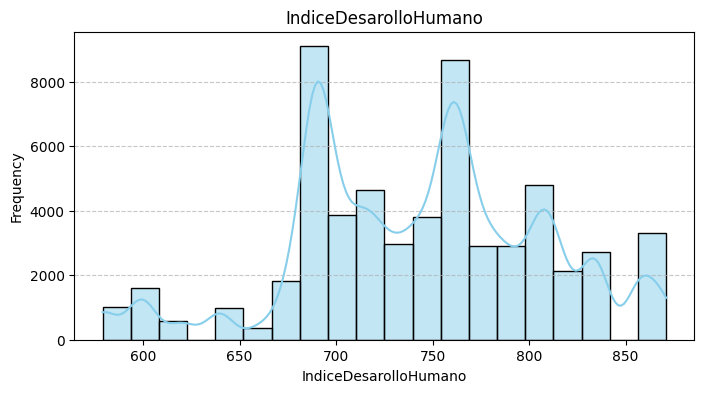

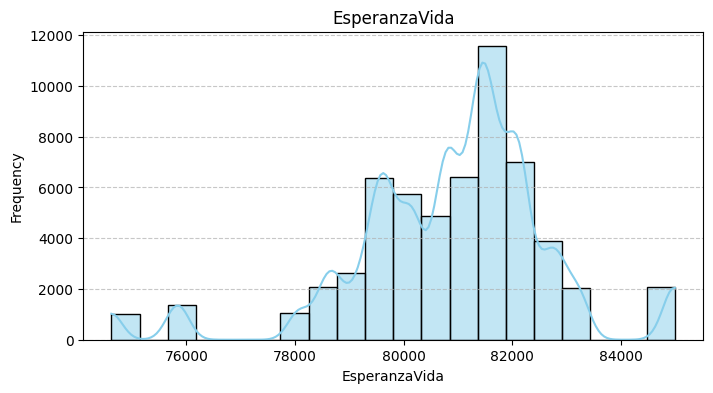

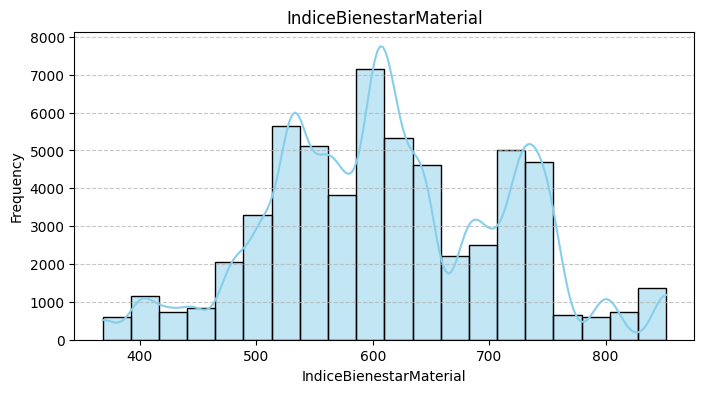

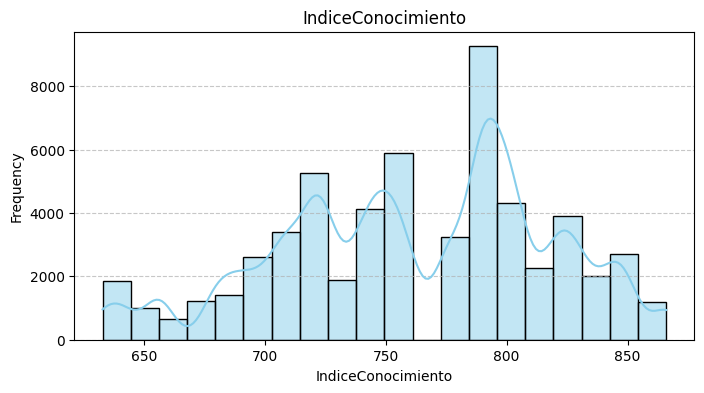

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Total_Asaltos','Total_Personas_Canton','IngresoPromedio','IndiceDesarolloHumano','EsperanzaVida','IndiceBienestarMaterial','IndiceConocimiento']

for col in cols:
    data = df_datos.select(col).toPandas()[col]
    
    plt.figure(figsize=(8,4))
    sns.histplot(data, bins=20, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


In [9]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# --- Columnas
categorical_cols = ['Canton','Provincia','Victima','Edad_Victima','Sexo_Victima',
                    'Nivel_Educativo','Sexo']

numeric_cols = ['Total_Asaltos','Total_Personas_Canton',
                'IngresoPromedio','IndiceDesarolloHumano','EsperanzaVida',
                'IndiceBienestarMaterial','IndiceConocimiento']

target = 'ASALTO_ARMADO_NUM'

# --- 1️⃣ Aplicar StringIndexer a columnas categóricas
for c in categorical_cols:
    indexer = StringIndexer(inputCol=c, outputCol=c + "_num", handleInvalid="keep")
    df_datos = indexer.fit(df_datos).transform(df_datos)

# --- 2️⃣ Preparar lista de columnas para VectorAssembler
input_cols = [c + "_num" for c in categorical_cols] + numeric_cols

# --- 3️⃣ Drop filas con NULLs en columnas numéricas
#df_final = df_datos.dropna(subset=numeric_cols)

# --- 4️⃣ VectorAssembler
assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol='features'
)

vector_df = assembler.transform(df_datos).select('features', target)

In [10]:
vector_df.show()

25/11/15 22:36:25 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------------+-----------------+
|            features|ASALTO_ARMADO_NUM|
+--------------------+-----------------+
|[12.0,2.0,0.0,0.0...|                0|
|[12.0,2.0,0.0,2.0...|                0|
|[12.0,2.0,0.0,0.0...|                1|
|[12.0,2.0,0.0,0.0...|                0|
|[12.0,2.0,0.0,1.0...|                1|
|[12.0,2.0,0.0,3.0...|                0|
|[12.0,2.0,0.0,2.0...|                1|
|[12.0,2.0,0.0,1.0...|                0|
|[12.0,2.0,0.0,2.0...|                0|
|[12.0,2.0,0.0,0.0...|                0|
|[12.0,2.0,0.0,0.0...|                1|
|[12.0,2.0,0.0,0.0...|                1|
|[12.0,2.0,0.0,1.0...|                0|
|[12.0,2.0,0.0,3.0...|                1|
|[12.0,2.0,0.0,3.0...|                0|
|[18.0,4.0,0.0,1.0...|                1|
|[18.0,4.0,0.0,2.0...|                0|
|[18.0,4.0,0.0,0.0...|                1|
|[18.0,4.0,0.0,0.0...|                0|
|[18.0,4.0,0.0,2.0...|                0|
+--------------------+-----------------+
only showing top

# Inspección de datos
Previo a entrenar el modelo es común que se realice algún tipo de descripción de los datos, para tener una idea del tipo de problema con el que nos enfrentamos. A continuación, algunas operacions útiles que podemos usar.


25/11/15 22:36:30 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/11/15 22:36:31 WARN PearsonCorrelation: Pearson correlation matrix contains NaN values.


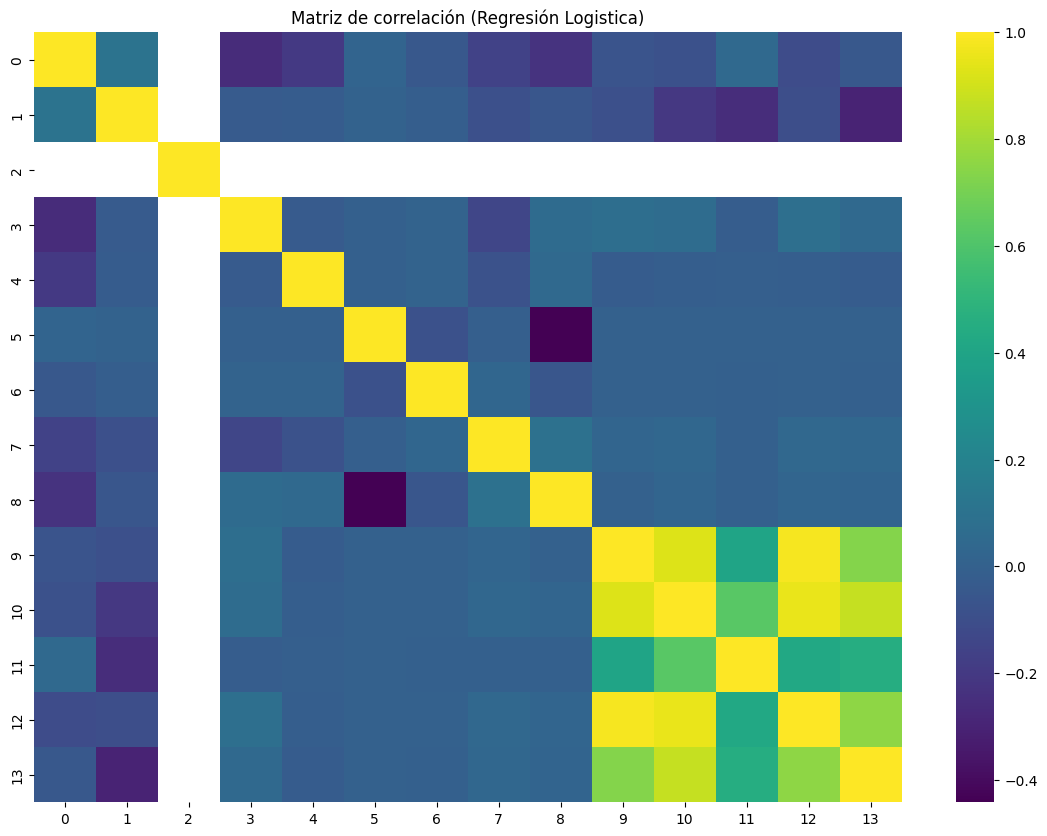

Features del vector:
0: Canton_num
1: Provincia_num
2: Victima_num
3: Edad_Victima_num
4: Sexo_Victima_num
5: Nivel_Educativo_num
6: Sexo_num
7: Total_Asaltos
8: Total_Personas_Canton
9: IngresoPromedio
10: IndiceDesarolloHumano
11: EsperanzaVida
12: IndiceBienestarMaterial
13: IndiceConocimiento


In [11]:
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import seaborn as sns

# Con la representación de vectores podemos calcular correlaciones

# --- matriz de correlación
pearson_matrix = Correlation.corr(vector_df, 'features', 'pearson').collect()[0][0]
corr_array = pearson_matrix.toArray()

# --- 2️⃣  heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_array, annot=False, cmap='viridis')
plt.title("Matriz de correlación (Regresión Logistica)")
plt.show()

# --- 3️⃣ feature 
print("Features del vector:")
for i, col_name in enumerate(input_cols):
    print(f"{i}: {col_name}")


## Estandarización


In [12]:
from pyspark.ml.feature import StandardScaler

standard_scaler = StandardScaler(inputCol='features', outputCol='scaled')
scale_model = standard_scaler.fit(vector_df)

scaled_df = scale_model.transform(vector_df)
scaled_df.show()

+--------------------+-----------------+--------------------+
|            features|ASALTO_ARMADO_NUM|              scaled|
+--------------------+-----------------+--------------------+
|[12.0,2.0,0.0,0.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,2.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,0.0...|                1|[0.60232680827913...|
|[12.0,2.0,0.0,0.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,1.0...|                1|[0.60232680827913...|
|[12.0,2.0,0.0,3.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,2.0...|                1|[0.60232680827913...|
|[12.0,2.0,0.0,1.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,2.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,0.0...|                0|[0.60232680827913...|
|[12.0,2.0,0.0,0.0...|                1|[0.60232680827913...|
|[12.0,2.0,0.0,0.0...|                1|[0.60232680827913...|
|[12.0,2.0,0.0,1.0...|                0|[0.60232680827913...|
|[12.0,2

## Entrenamiento de Modelos

### Modelo 1 LogisticRegression

In [13]:
# Entrenar con k fold

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# dividir en entrenar / validar 
train_df, val_df = vector_df.randomSplit([0.8, 0.2], seed=42)

# === Modelo 1 regresion logistica  ===
lr = LogisticRegression(featuresCol="features", labelCol="ASALTO_ARMADO_NUM")

# Grilla de Prametros
paramGrid_lr = (ParamGridBuilder()
                .addGrid(lr.regParam, [0.01, 0.1, 0.5])
                .build())

# Funcion de evaluacion 
evaluator = BinaryClassificationEvaluator(labelCol="ASALTO_ARMADO_NUM", metricName="areaUnderROC")

# validacion cruzada en 5 folds 
cv_lr = CrossValidator(estimator=lr,
                       estimatorParamMaps=paramGrid_lr,
                       evaluator=evaluator,
                       numFolds=5)

# Entramiento del modelo
cv_model_lr = cv_lr.fit(train_df)

# predicciones en VALIDACION
predictions_lr = cv_model_lr.transform(val_df)

# predicciones en TRAIN  <<<<<< THIS IS THE ONLY LINE ADDED
train_predictions_lr = cv_model_lr.transform(train_df)

## area bajo la curva 
print("\n=== AUC por combinación de parámetros (5 folds) ===")
for i, avg in enumerate(cv_model_lr.avgMetrics):
    print(f"Combinación {i+1}: AUC promedio = {avg:.4f}")



=== AUC por combinación de parámetros (5 folds) ===
Combinación 1: AUC promedio = 0.5359
Combinación 2: AUC promedio = 0.5329
Combinación 3: AUC promedio = 0.5300


In [14]:
# Evaluadores
binary_eval = BinaryClassificationEvaluator(labelCol="ASALTO_ARMADO_NUM")
multi_eval  = MulticlassClassificationEvaluator(labelCol="ASALTO_ARMADO_NUM")

def compute_metrics(pred_df):
    return {
        "AUC ROC": binary_eval.evaluate(pred_df, {binary_eval.metricName: "areaUnderROC"}),
        "AUC PR": binary_eval.evaluate(pred_df, {binary_eval.metricName: "areaUnderPR"}),
        "Accuracy": multi_eval.setMetricName("accuracy").evaluate(pred_df),
        "Precision": multi_eval.setMetricName("weightedPrecision").evaluate(pred_df),
        "Recall": multi_eval.setMetricName("weightedRecall").evaluate(pred_df),
        "F1": multi_eval.setMetricName("f1").evaluate(pred_df)
    }

# Metrics
metrics_train = compute_metrics(train_predictions_lr)
metrics_val   = compute_metrics(predictions_lr)

print("\n=== MÉTRICAS LOGISTIC REGRESSION - TRAIN ===")
for k, v in metrics_train.items():
    print(f"{k:15s}: {v:.4f}")

print("\n=== MÉTRICAS LOGISTIC REGRESSION - VALIDACIÓN ===")
for k, v in metrics_val.items():
    print(f"{k:15s}: {v:.4f}")



=== MÉTRICAS LOGISTIC REGRESSION - TRAIN ===
AUC ROC        : 0.5388
AUC PR         : 0.5488
Accuracy       : 0.5327
Precision      : 0.5308
Recall         : 0.5327
F1             : 0.4973

=== MÉTRICAS LOGISTIC REGRESSION - VALIDACIÓN ===
AUC ROC        : 0.5407
AUC PR         : 0.5468
Accuracy       : 0.5291
Precision      : 0.5302
Recall         : 0.5291
F1             : 0.4931


In [15]:
print("\n=== Ejemplo de predicciones ===")
predictions_lr.select("probability", "prediction", "ASALTO_ARMADO_num").show(10, truncate=False)



=== Ejemplo de predicciones ===


+----------------------------------------+----------+-----------------+
|probability                             |prediction|ASALTO_ARMADO_num|
+----------------------------------------+----------+-----------------+
|[0.5136066214463991,0.4863933785536009] |0.0       |0                |
|[0.5243070171699689,0.47569298283003114]|0.0       |0                |
|[0.5030273116433711,0.4969726883566289] |0.0       |0                |
|[0.48590499160048745,0.5140950083995126]|1.0       |1                |
|[0.4936164402890669,0.5063835597109331] |1.0       |1                |
|[0.5030590886647602,0.49694091133523977]|0.0       |1                |
|[0.5171186353233878,0.48288136467661225]|0.0       |0                |
|[0.49716100925918044,0.5028389907408195]|1.0       |0                |
|[0.36270415729222644,0.6372958427077735]|1.0       |1                |
|[0.3672438167722845,0.6327561832277155] |1.0       |0                |
+----------------------------------------+----------+-----------

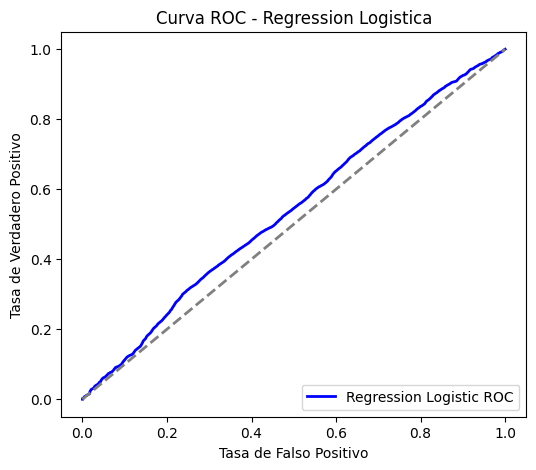

AUC ROC - Regression Logistica: 0.5388


In [16]:
from pyspark.ml.classification import LogisticRegression
import matplotlib.pyplot as plt

# ROC data de los resumen del entrenamiento
lr_model = cv_model_lr.bestModel  # mejor modelo de regessions de validacion cruzada
training_summary = lr_model.summary

# Obetenr puntos ROC 
roc = training_summary.roc.toPandas()  # Nos da FPR, TPR

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(roc['FPR'], roc['TPR'], color='blue', lw=2, label='Regression Logistic ROC')
plt.plot([0,1],[0,1], color='gray', lw=2, linestyle='--')
plt.xlabel('Tasa de Falso Positivo')
plt.ylabel('Tasa de Verdadero Positivo')
plt.title('Curva ROC - Regression Logistica')
plt.legend(loc='lower right')
plt.show()

# AUC
auc_lr = training_summary.areaUnderROC
print(f"AUC ROC - Regression Logistica: {auc_lr:.4f}")


## Modelo 2 RandomForestClassifier

In [17]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# --- Columnas
categorical_cols = ['Canton','Provincia','Victima','Edad_Victima','Sexo_Victima','Nivel_Educativo','Sexo']
numeric_cols = ['Total_Asaltos','Total_Personas_Canton','IngresoPromedio','IndiceDesarolloHumano',
                'EsperanzaVida','IndiceBienestarMaterial','IndiceConocimiento']
target = 'ASALTO_ARMADO_NUM'

# --- Remueve columnas existing con  _num si hubiera para evitar errores
for c in categorical_cols:
    if c + "_num" in df_datos.columns:
        df_datos = df_datos.drop(c + "_num")

# ---  Convertir categoricas a numericas 
df_datos_tree = df_datos  # 
for c in categorical_cols:
    indexer = StringIndexer(inputCol=c, outputCol=c + "_num", handleInvalid="keep")
    df_datos_tree = indexer.fit(df_datos_tree).transform(df_datos_tree)

# ---  Unir todas las features 
input_cols_tree = [c + "_num" for c in categorical_cols] + numeric_cols
assembler_tree = VectorAssembler(inputCols=input_cols_tree, outputCol="features_tree")
df_tree = assembler_tree.transform(df_datos_tree).select("features_tree", target)

# --- dividir en entrenamiento y validacion 
train_df, val_df = df_tree.randomSplit([0.8, 0.2], seed=42)

# ---  Random Forest (ajustar maxBins para evitar errores por alta cardinalidad )
rf = RandomForestClassifier(featuresCol="features_tree", labelCol=target, seed=42, maxBins=100)

# ---  Validacion cruzarada con hyperparameter grid
paramGrid_rf = (ParamGridBuilder()
                .addGrid(rf.numTrees, [50, 100])
                .addGrid(rf.maxDepth, [5, 10])
                .build())

evaluator = BinaryClassificationEvaluator(labelCol=target, metricName="areaUnderROC")

cv_rf = CrossValidator(estimator=rf,
                       estimatorParamMaps=paramGrid_rf,
                       evaluator=evaluator,
                       numFolds=5,
                       parallelism=2)

# --- Entrenar y predecir
cv_model_rf = cv_rf.fit(train_df)
predictions_rf = cv_model_rf.transform(val_df)

# --- Print el promedio del AUC para cada combinacion de hyperparametros
print("\n=== AUC per combination (5 folds - Random Forest) ===")
for i, avg in enumerate(cv_model_rf.avgMetrics):
    print(f"Combination {i+1}: Average AUC = {avg:.4f}")


25/11/15 22:38:14 WARN DAGScheduler: Broadcasting large task binary with size 1062.5 KiB
25/11/15 22:38:17 WARN DAGScheduler: Broadcasting large task binary with size 1504.3 KiB
25/11/15 22:38:21 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/11/15 22:38:24 WARN DAGScheduler: Broadcasting large task binary with size 1633.6 KiB
25/11/15 22:38:42 WARN DAGScheduler: Broadcasting large task binary with size 1357.2 KiB
25/11/15 22:38:47 WARN DAGScheduler: Broadcasting large task binary with size 2028.6 KiB
25/11/15 22:38:52 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/11/15 22:38:58 WARN DAGScheduler: Broadcasting large task binary with size 4.1 MiB
25/11/15 22:39:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/11/15 22:39:20 WARN DAGScheduler: Broadcasting large task binary with size 1007.8 KiB
25/11/15 22:39:22 WARN DAGScheduler: Broadcasting large task binary with size 1416.3 KiB
25/11/15 22:39:26 WARN DAGSchedul


=== AUC per combination (5 folds - Random Forest) ===
Combination 1: Average AUC = 0.7165
Combination 2: Average AUC = 0.9267
Combination 3: Average AUC = 0.7244
Combination 4: Average AUC = 0.9376


25/11/15 22:44:14 WARN PearsonCorrelation: Pearson correlation matrix contains NaN values.


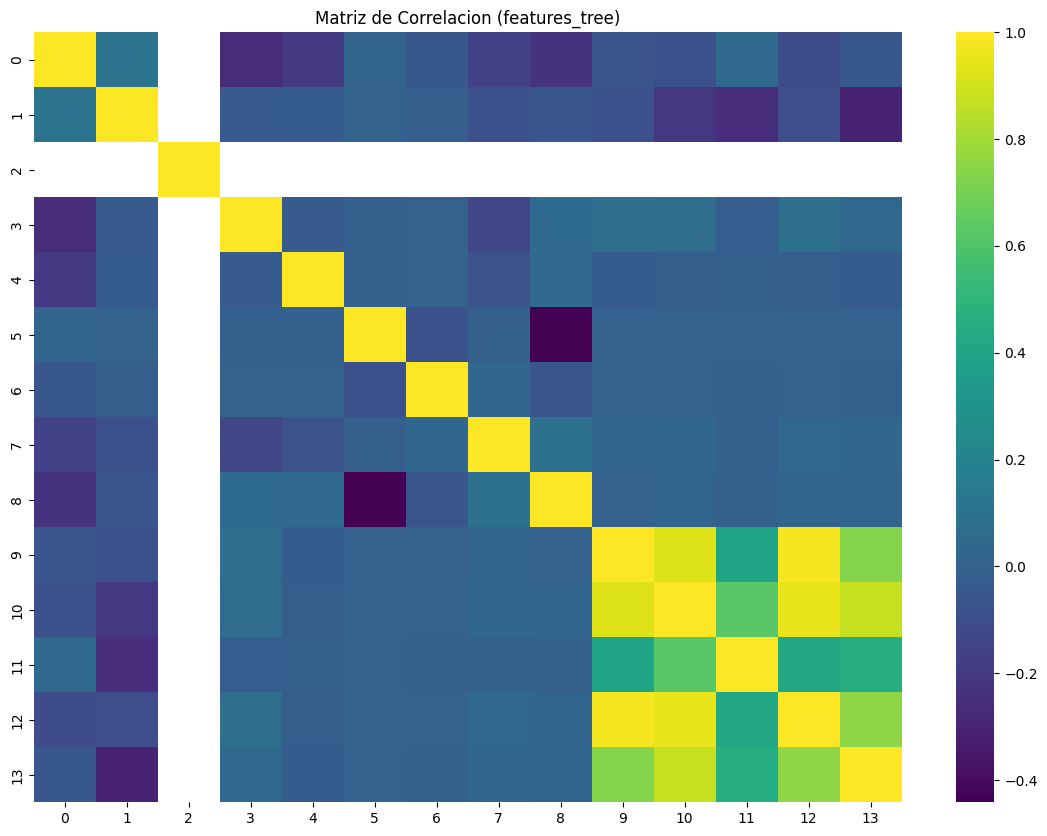

Feature order in features_tree:
0: Canton_num
1: Provincia_num
2: Victima_num
3: Edad_Victima_num
4: Sexo_Victima_num
5: Nivel_Educativo_num
6: Sexo_num
7: Total_Asaltos
8: Total_Personas_Canton
9: IngresoPromedio
10: IndiceDesarolloHumano
11: EsperanzaVida
12: IndiceBienestarMaterial
13: IndiceConocimiento


In [18]:
from pyspark.ml.stat import Correlation
import matplotlib.pyplot as plt
import seaborn as sns

# --- Calcular la matriz de correlacion de las features_tree del vector
pearson_matrix = Correlation.corr(df_tree, "features_tree", "pearson").collect()[0][0]
corr_array = pearson_matrix.toArray()

# ---  heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_array, annot=False, cmap='viridis')
plt.title("Matriz de Correlacion (features_tree)")
plt.show()

# --- Imprimir las feature de la matriz de correlacion
print("Feature order in features_tree:")
for i, col_name in enumerate(input_cols_tree):
    print(f"{i}: {col_name}")


In [19]:
# --- 1. Predictions on training and validation
train_predictions_rf = cv_model_rf.transform(train_df)
val_predictions_rf = cv_model_rf.transform(val_df)

# --- 2. Evaluators
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

multi_eval = MulticlassClassificationEvaluator(labelCol=target)
binary_eval = BinaryClassificationEvaluator(labelCol=target)

# --- 3. Function to compute all metrics
def compute_metrics(pred_df):
    return {
        "AUC ROC": binary_eval.evaluate(pred_df, {binary_eval.metricName: "areaUnderROC"}),
        "AUC PR": binary_eval.evaluate(pred_df, {binary_eval.metricName: "areaUnderPR"}),
        "Accuracy": multi_eval.setMetricName("accuracy").evaluate(pred_df),
        "Precision": multi_eval.setMetricName("weightedPrecision").evaluate(pred_df),
        "Recall": multi_eval.setMetricName("weightedRecall").evaluate(pred_df),
        "F1": multi_eval.setMetricName("f1").evaluate(pred_df)
    }

# --- 4. Compute metrics for train and validation
metrics_train = compute_metrics(train_predictions_rf)
metrics_val   = compute_metrics(val_predictions_rf)

# --- 5. Print results
print("\n=== MÉTRICAS RANDOM FOREST - TRAIN ===")
for k, v in metrics_train.items():
    print(f"{k:15s}: {v:.4f}")

print("\n=== MÉTRICAS RANDOM FOREST - VALIDACIÓN ===")
for k, v in metrics_val.items():
    print(f"{k:15s}: {v:.4f}")


25/11/15 22:44:15 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/11/15 22:44:21 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/11/15 22:44:28 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:44:33 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:44:38 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:44:44 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:44:49 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/11/15 22:44:52 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
25/11/15 22:44:55 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:44:58 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:45:01 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/11/15 22:45:03 WARN DAGScheduler: Broadcasting larg


=== MÉTRICAS RANDOM FOREST - TRAIN ===
AUC ROC        : 0.9455
AUC PR         : 0.9474
Accuracy       : 0.8701
Precision      : 0.8712
Recall         : 0.8701
F1             : 0.8698

=== MÉTRICAS RANDOM FOREST - VALIDACIÓN ===
AUC ROC        : 0.9349
AUC PR         : 0.9354
Accuracy       : 0.8559
Precision      : 0.8569
Recall         : 0.8559
F1             : 0.8556


In [20]:
print("\n=== Ejemplo de predicciones (Random Forest) ===")
predictions_rf.select(
    "probability",        # predecir probabilidades para cada clase
    "prediction",         # prediccion 
    "ASALTO_ARMADO_NUM"   # valor verdadero
).show(20, truncate=False)




=== Ejemplo de predicciones (Random Forest) ===


25/11/15 22:45:06 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


+----------------------------------------+----------+-----------------+
|probability                             |prediction|ASALTO_ARMADO_NUM|
+----------------------------------------+----------+-----------------+
|[0.5988778136608262,0.4011221863391738] |0.0       |0                |
|[0.6579603266732228,0.34203967332677726]|0.0       |0                |
|[0.7349499027271882,0.26505009727281187]|0.0       |0                |
|[0.310026118208059,0.6899738817919411]  |1.0       |1                |
|[0.5065247431973738,0.49347525680262627]|0.0       |1                |
|[0.349269478490006,0.650730521509994]   |1.0       |1                |
|[0.6344812502340331,0.365518749765967]  |0.0       |0                |
|[0.8627290426158816,0.13727095738411846]|0.0       |0                |
|[0.36674501868270165,0.6332549813172983]|1.0       |1                |
|[0.6778350405821251,0.32216495941787493]|0.0       |0                |
|[0.3774656783119297,0.6225343216880703] |1.0       |1          

25/11/15 22:45:08 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


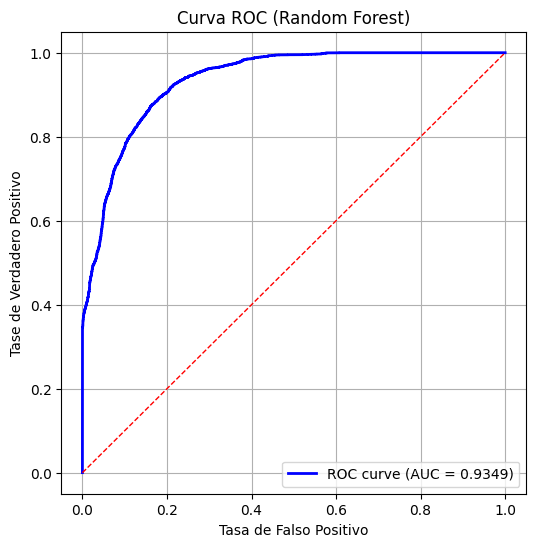

In [21]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

# ---  Extrar le probabilidad de la clase positiva del la estructura del vector distribuido
def extract_prob(prob_struct):
    return float(prob_struct.values[1])  # probabilida de clase 1

extract_prob_udf = udf(extract_prob, DoubleType())

preds_with_prob = predictions_rf.withColumn(
    "probability_class1", extract_prob_udf(col("probability"))
).select("probability_class1", "ASALTO_ARMADO_NUM")

# ---  Convetir a Pandas para graficar 
pdf = preds_with_prob.toPandas()
y_true = pdf["ASALTO_ARMADO_NUM"].values
y_scores = pdf["probability_class1"].values

# --- Calcular puntos ROC 
# Order por score predecido descendiendo
sorted_indices = (-y_scores).argsort()
y_scores_sorted = y_scores[sorted_indices]
y_true_sorted = y_true[sorted_indices]

P = sum(y_true)
N = len(y_true) - P

tpr_list = []
fpr_list = []

tp = 0
fp = 0

for i in range(len(y_true_sorted)):
    if y_true_sorted[i] == 1:
        tp += 1
    else:
        fp += 1
    tpr_list.append(tp / P)
    fpr_list.append(fp / N)

# ---  Calcular AUC approximado
auc = 0
for i in range(1, len(fpr_list)):
    auc += (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1]) / 2

# --- Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr_list, tpr_list, color="blue", lw=2, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0,1], [0,1], color="red", lw=1, linestyle="--")
plt.xlabel("Tasa de Falso Positivo")
plt.ylabel("Tase de Verdadero Positivo")
plt.title("Curva ROC (Random Forest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
